# Thesis Experiment Analysis: Learning Insight Task

This notebook provides a comprehensive analysis of the Learning Insight task experiment results, including:
- Bar plots for each prompt technique grouped by LLM model
- Line graphs for metric trends across prompt techniques
- Radar charts for latency comparison across models and prompts
- Overall performance plots for the entire Learning Insight task
- Heatmaps, box plots, and ranking tables for deeper insights

**Dataset**: `Final_Thesis_Experiment_Results_Insight.xlsx` (Sheet: `Task 4  Learning Insight`)

## 1. Setup and Dependencies

In [ ]:
!pip install openpyxl matplotlib seaborn pandas numpy --quiet

In [ ]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Preprocessing

In [ ]:
from google.colab import files
uploaded = files.upload()

FILE_PATH  = "Final_Thesis_Experiment_Results_Insight.xlsx"
SHEET_NAME = "Task 4  Learning Insight"  # two spaces in sheet name

raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Rename model column (trailing space in source)
raw_df.rename(columns={"LLM Model ": "Model"}, inplace=True)

df = raw_df.copy()
df["Prompting"] = df["Prompting"].str.strip()
df["Model"]     = df["Model"].str.strip()

# Map API model names to clean display labels
MODEL_LABELS = {
    "llama-3.1-8b-instant":    "LLaMA-3.1-8B",
    "llama-3.3-70b-versatile": "LLaMA-3.3-70B",
    "openai/gpt-oss-120b":     "GPT-OSS-120B",
    "openai/gpt-oss-20b":      "GPT-OSS-20B",
    "qwen/qwen3-32b":          "Qwen3-32B",
}
df["Model"] = df["Model"].map(MODEL_LABELS).fillna(df["Model"])

# Derive directly from data
MODELS  = ["LLaMA-3.1-8B", "LLaMA-3.3-70B", "GPT-OSS-120B", "GPT-OSS-20B", "Qwen3-32B"]
PROMPTS = df["Prompting"].unique().tolist()

QUALITY_METRICS = [
    "avg_field_completeness",
    "avg_bert_f1",
    "avg_rouge_l",
    "avg_field_bleu",
    "composite_score",
]
LATENCY_METRICS = ["avg_latency_sec", "min_latency_sec", "max_latency_sec"]

METRIC_LABELS = {
    "avg_field_completeness": "Field Completeness",
    "avg_bert_f1":            "BERTScore F1",
    "avg_rouge_l":            "ROUGE-L",
    "avg_field_bleu":         "Field BLEU",
    "composite_score":        "Composite Score",
    "avg_latency_sec":        "Avg Latency (s)",
    "min_latency_sec":        "Min Latency (s)",
    "max_latency_sec":        "Max Latency (s)",
}

MODEL_COLORS = {
    "LLaMA-3.1-8B":  "#4C72B0",
    "LLaMA-3.3-70B": "#DD8452",
    "GPT-OSS-120B":  "#55A868",
    "GPT-OSS-20B":   "#C44E52",
    "Qwen3-32B":     "#8172B2",
}

# Ensure all metric columns are numeric
for col in QUALITY_METRICS + LATENCY_METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape: {df.shape}")
print(f"\nPrompt techniques ({len(PROMPTS)}):")
for p in PROMPTS:
    print(f"  {p}")
print(f"\nModels ({len(MODELS)}):")
for m in MODELS:
    print(f"  {m}")
print(f"\nRows per Model:")
print(df["Model"].value_counts().to_string())
df.head(10)

Saving Final_Thesis_Experiment_Results_Insight.xlsx to Final_Thesis_Experiment_Results_Insight.xlsx
Shape: (40, 13)

Prompt techniques (8):
  Zero shot
  Few Shot
  Instruction
  Role Based
  Chain of Thoughts
  Tree of Thoughts
  ReAct
  Self Consistency

Models (5):
  LLaMA-3.1-8B
  LLaMA-3.3-70B
  GPT-OSS-120B
  GPT-OSS-20B
  Qwen3-32B

Rows per Model:
Model
LLaMA-3.1-8B     8
LLaMA-3.3-70B    8
GPT-OSS-120B     8
GPT-OSS-20B      8
Qwen3-32B        8


,Prompting,Model,temperature,total_samples,avg_field_completeness,avg_bert_f1,avg_rouge_l,avg_field_bleu,avg_latency_sec,min_latency_sec,max_latency_sec,total_latency_sec,composite_score
0,Zero shot,LLaMA-3.1-8B,0.2,25,1.0000,0.8610,0.2626,0.0919,1.1589,0.432,11.394,28.972,0.6607
1,Zero shot,LLaMA-3.3-70B,0.2,25,0.9933,0.8498,0.2512,0.0611,0.7059,0.539,1.082,17.648,0.6476
2,Zero shot,GPT-OSS-120B,0.2,25,1.0000,0.8560,0.2419,0.0678,1.2652,0.925,1.843,31.631,0.6510
3,Zero shot,GPT-OSS-20B,0.2,25,1.0000,0.8495,0.2268,0.0414,0.8719,0.588,1.368,21.797,0.6414
4,Zero shot,Qwen3-32B,0.2,25,1.0000,0.8553,0.2342,0.0463,2.2473,1.033,11.156,56.182,0.6459
5,Few Shot,LLaMA-3.1-8B,0.2,25,0.8667,0.7633,0.2417,0.0497,2.3863,0.421,17.817,59.657,0.5778
6,Few Shot,LLaMA-3.3-70B,0.2,25,1.0000,0.8673,0.2736,0.0626,0.8088,0.564,1.086,20.220,0.6610
7,Few Shot,GPT-OSS-120B,0.2,25,1.0000,0.8596,0.2435,0.0412,3.6008,1.598,18.147,90.020,0.6487
8,Few Shot,GPT-OSS-20B,0.2,25,0.9933,0.8546,0.2252,0.0264,4.5617,0.929,12.223,114.042,0.6392
9,Few Shot,Qwen3-32B,0.2,25,1.0000,0.8663,0.2716,0.0495,4.9126,1.117,22.374,122.815,0.6583


## 3. Bar Plots: One Figure per Prompt Technique

**Structure**: Each prompt technique produces one subplot.  
**X-axis**: LLM Models.  
**Grouped bars**: Each quality metric (Field Completeness, BERTScore F1, ROUGE-L, Field BLEU, Composite Score).

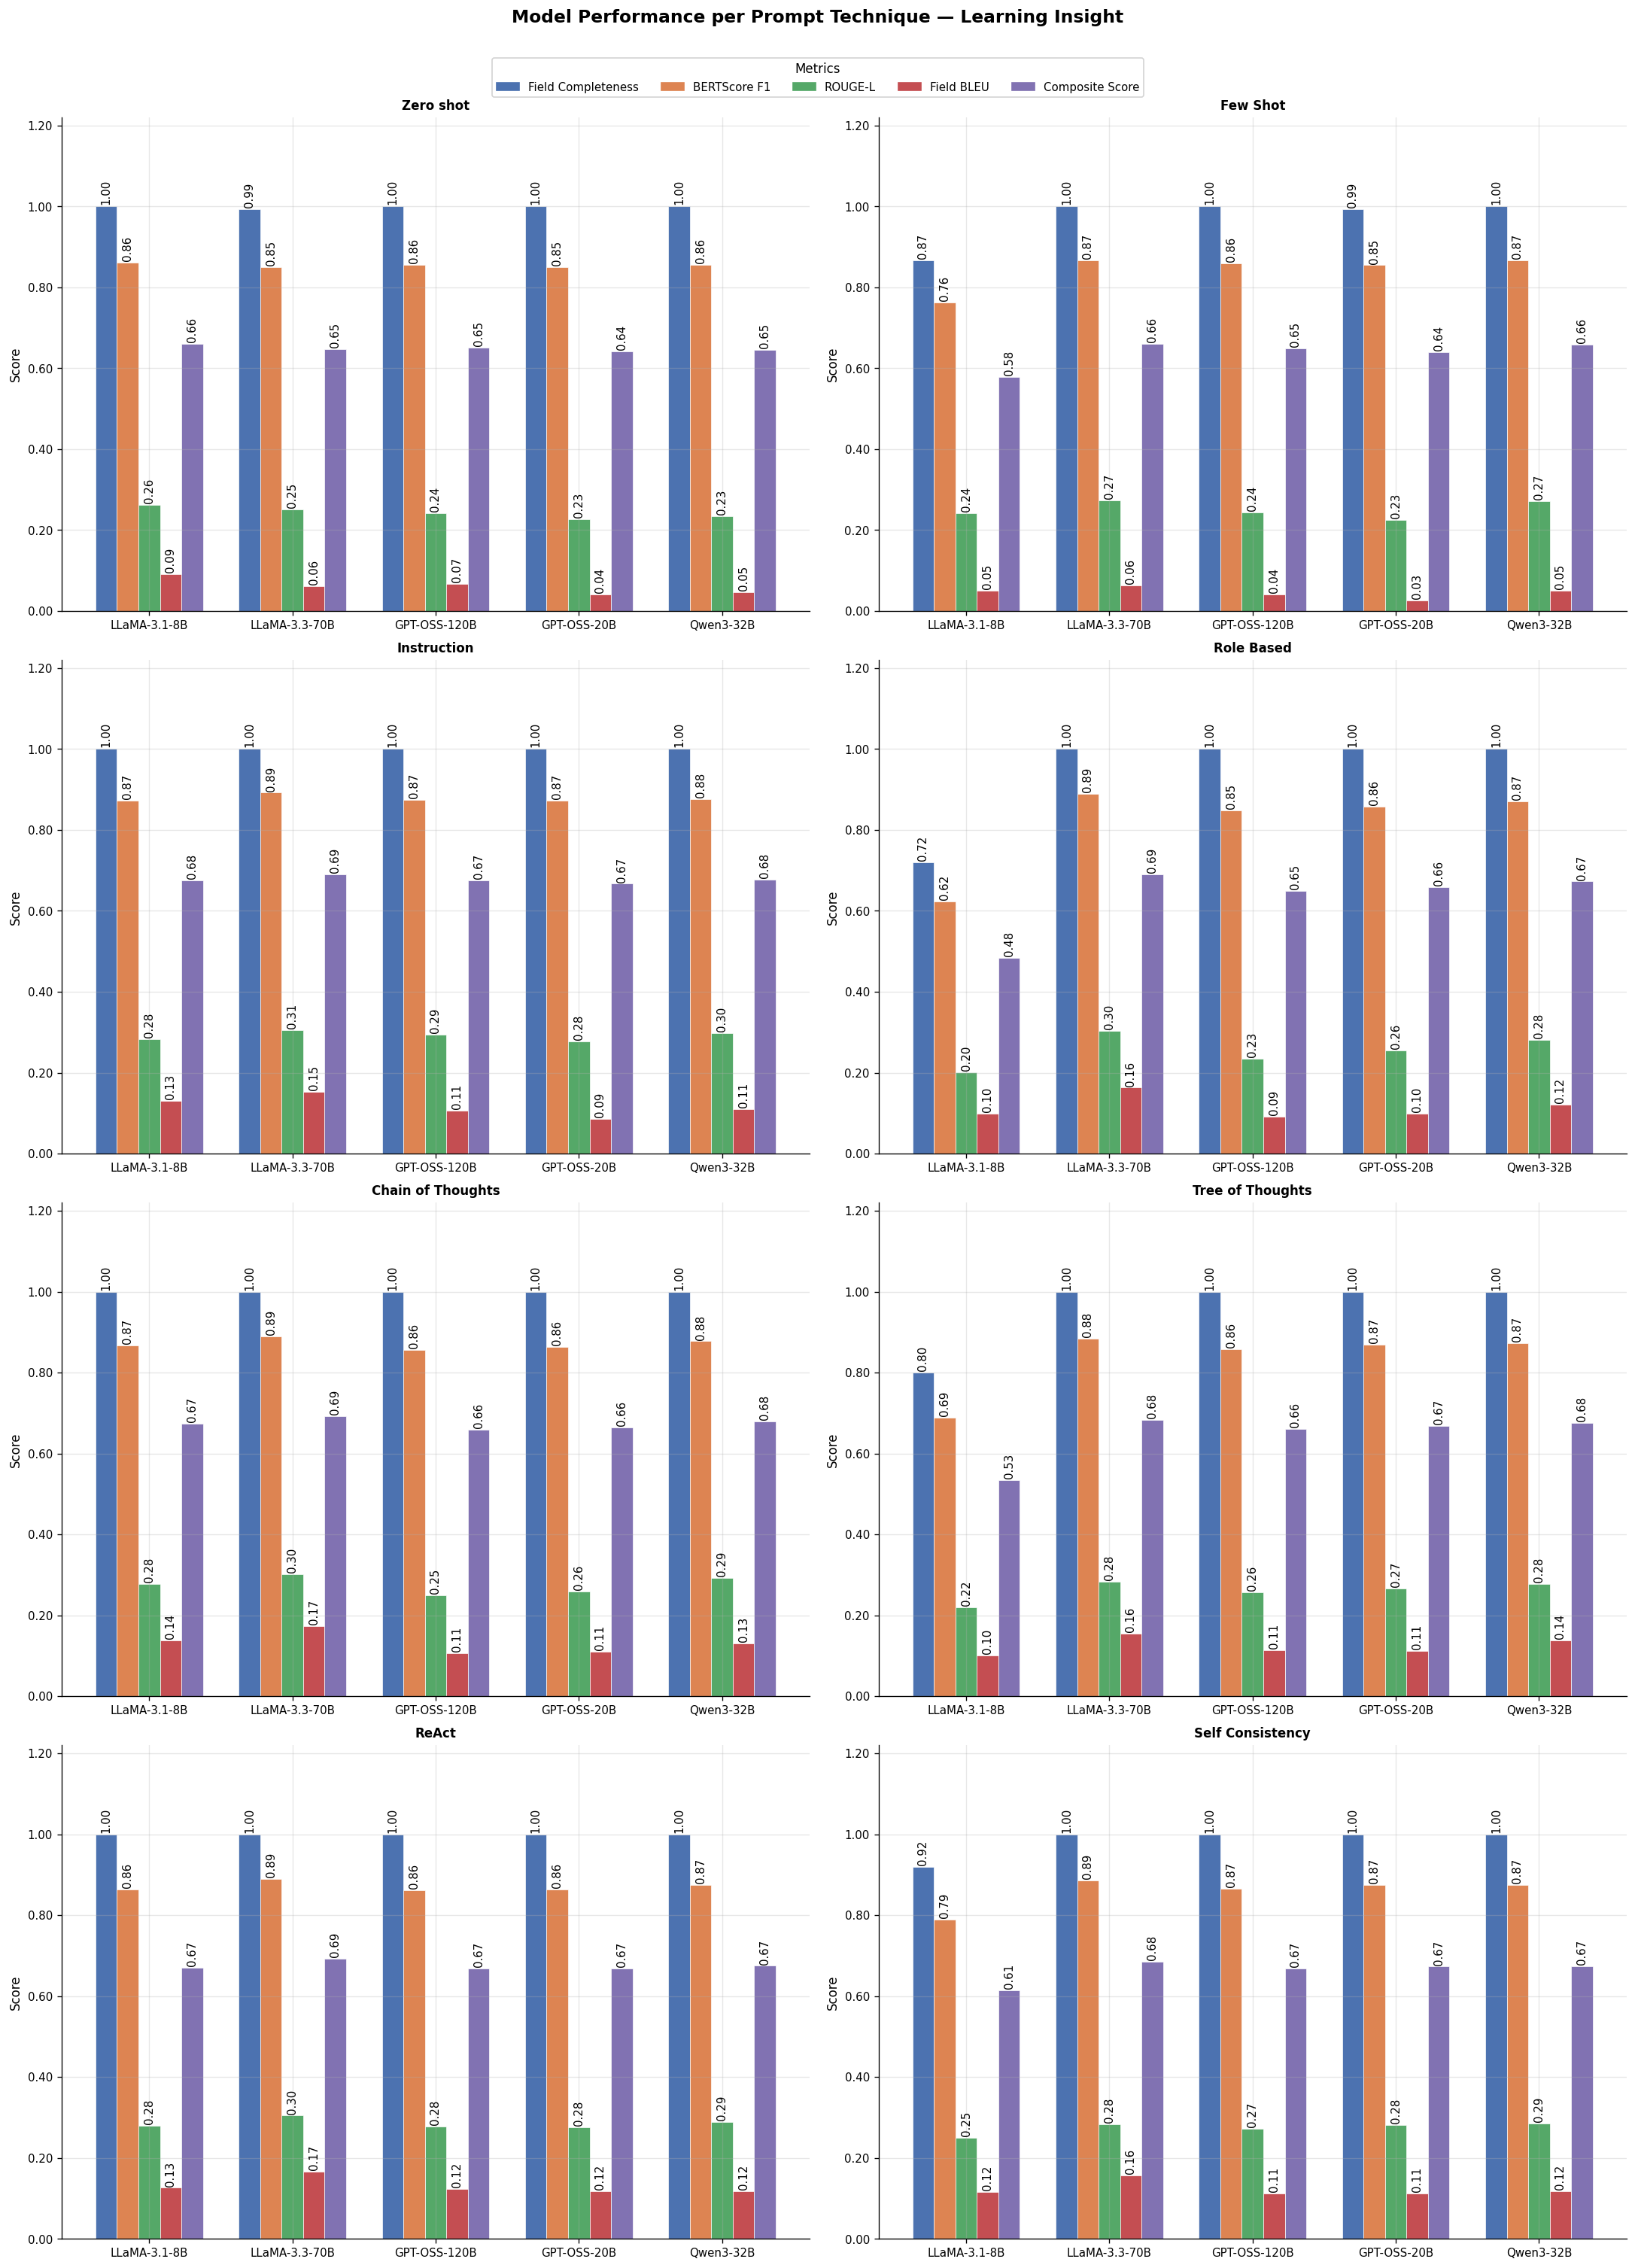

In [ ]:
METRIC_COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
]


def plot_prompt_bar(ax, data, prompt, metrics):
    """X-axis = Models, grouped bars = metrics, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg    = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics)
    x         = np.arange(n_models)
    bar_w     = 0.75 / n_metrics
    offsets   = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(
            x + offsets[i], vals, width=bar_w,
            label=METRIC_LABELS.get(metric, metric),
            color=color, edgecolor="white", linewidth=0.4,
        )
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=9, rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=9, ha="center")
    ax.set_ylabel("Score", fontsize=10)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_bar(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [
    plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
    for i in range(len(metrics_to_plot))
]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(
    metric_handles, metric_names, loc="upper center",
    ncol=len(metrics_to_plot), fontsize=9,
    bbox_to_anchor=(0.5, 1.02), frameon=True,
    title="Metrics", title_fontsize=10,
)
fig.suptitle(
    "Model Performance per Prompt Technique — Learning Insight",
    fontsize=14, fontweight="bold", y=1.04,
)
plt.savefig("li_bar_per_prompt.png", bbox_inches="tight")
plt.show()

## 4. Line Graphs: Metric Trends per Prompt Technique

**Structure**: One subplot per prompt technique.  
**X-axis**: LLM Models.  
**Lines**: Each metric is a separate line with markers.

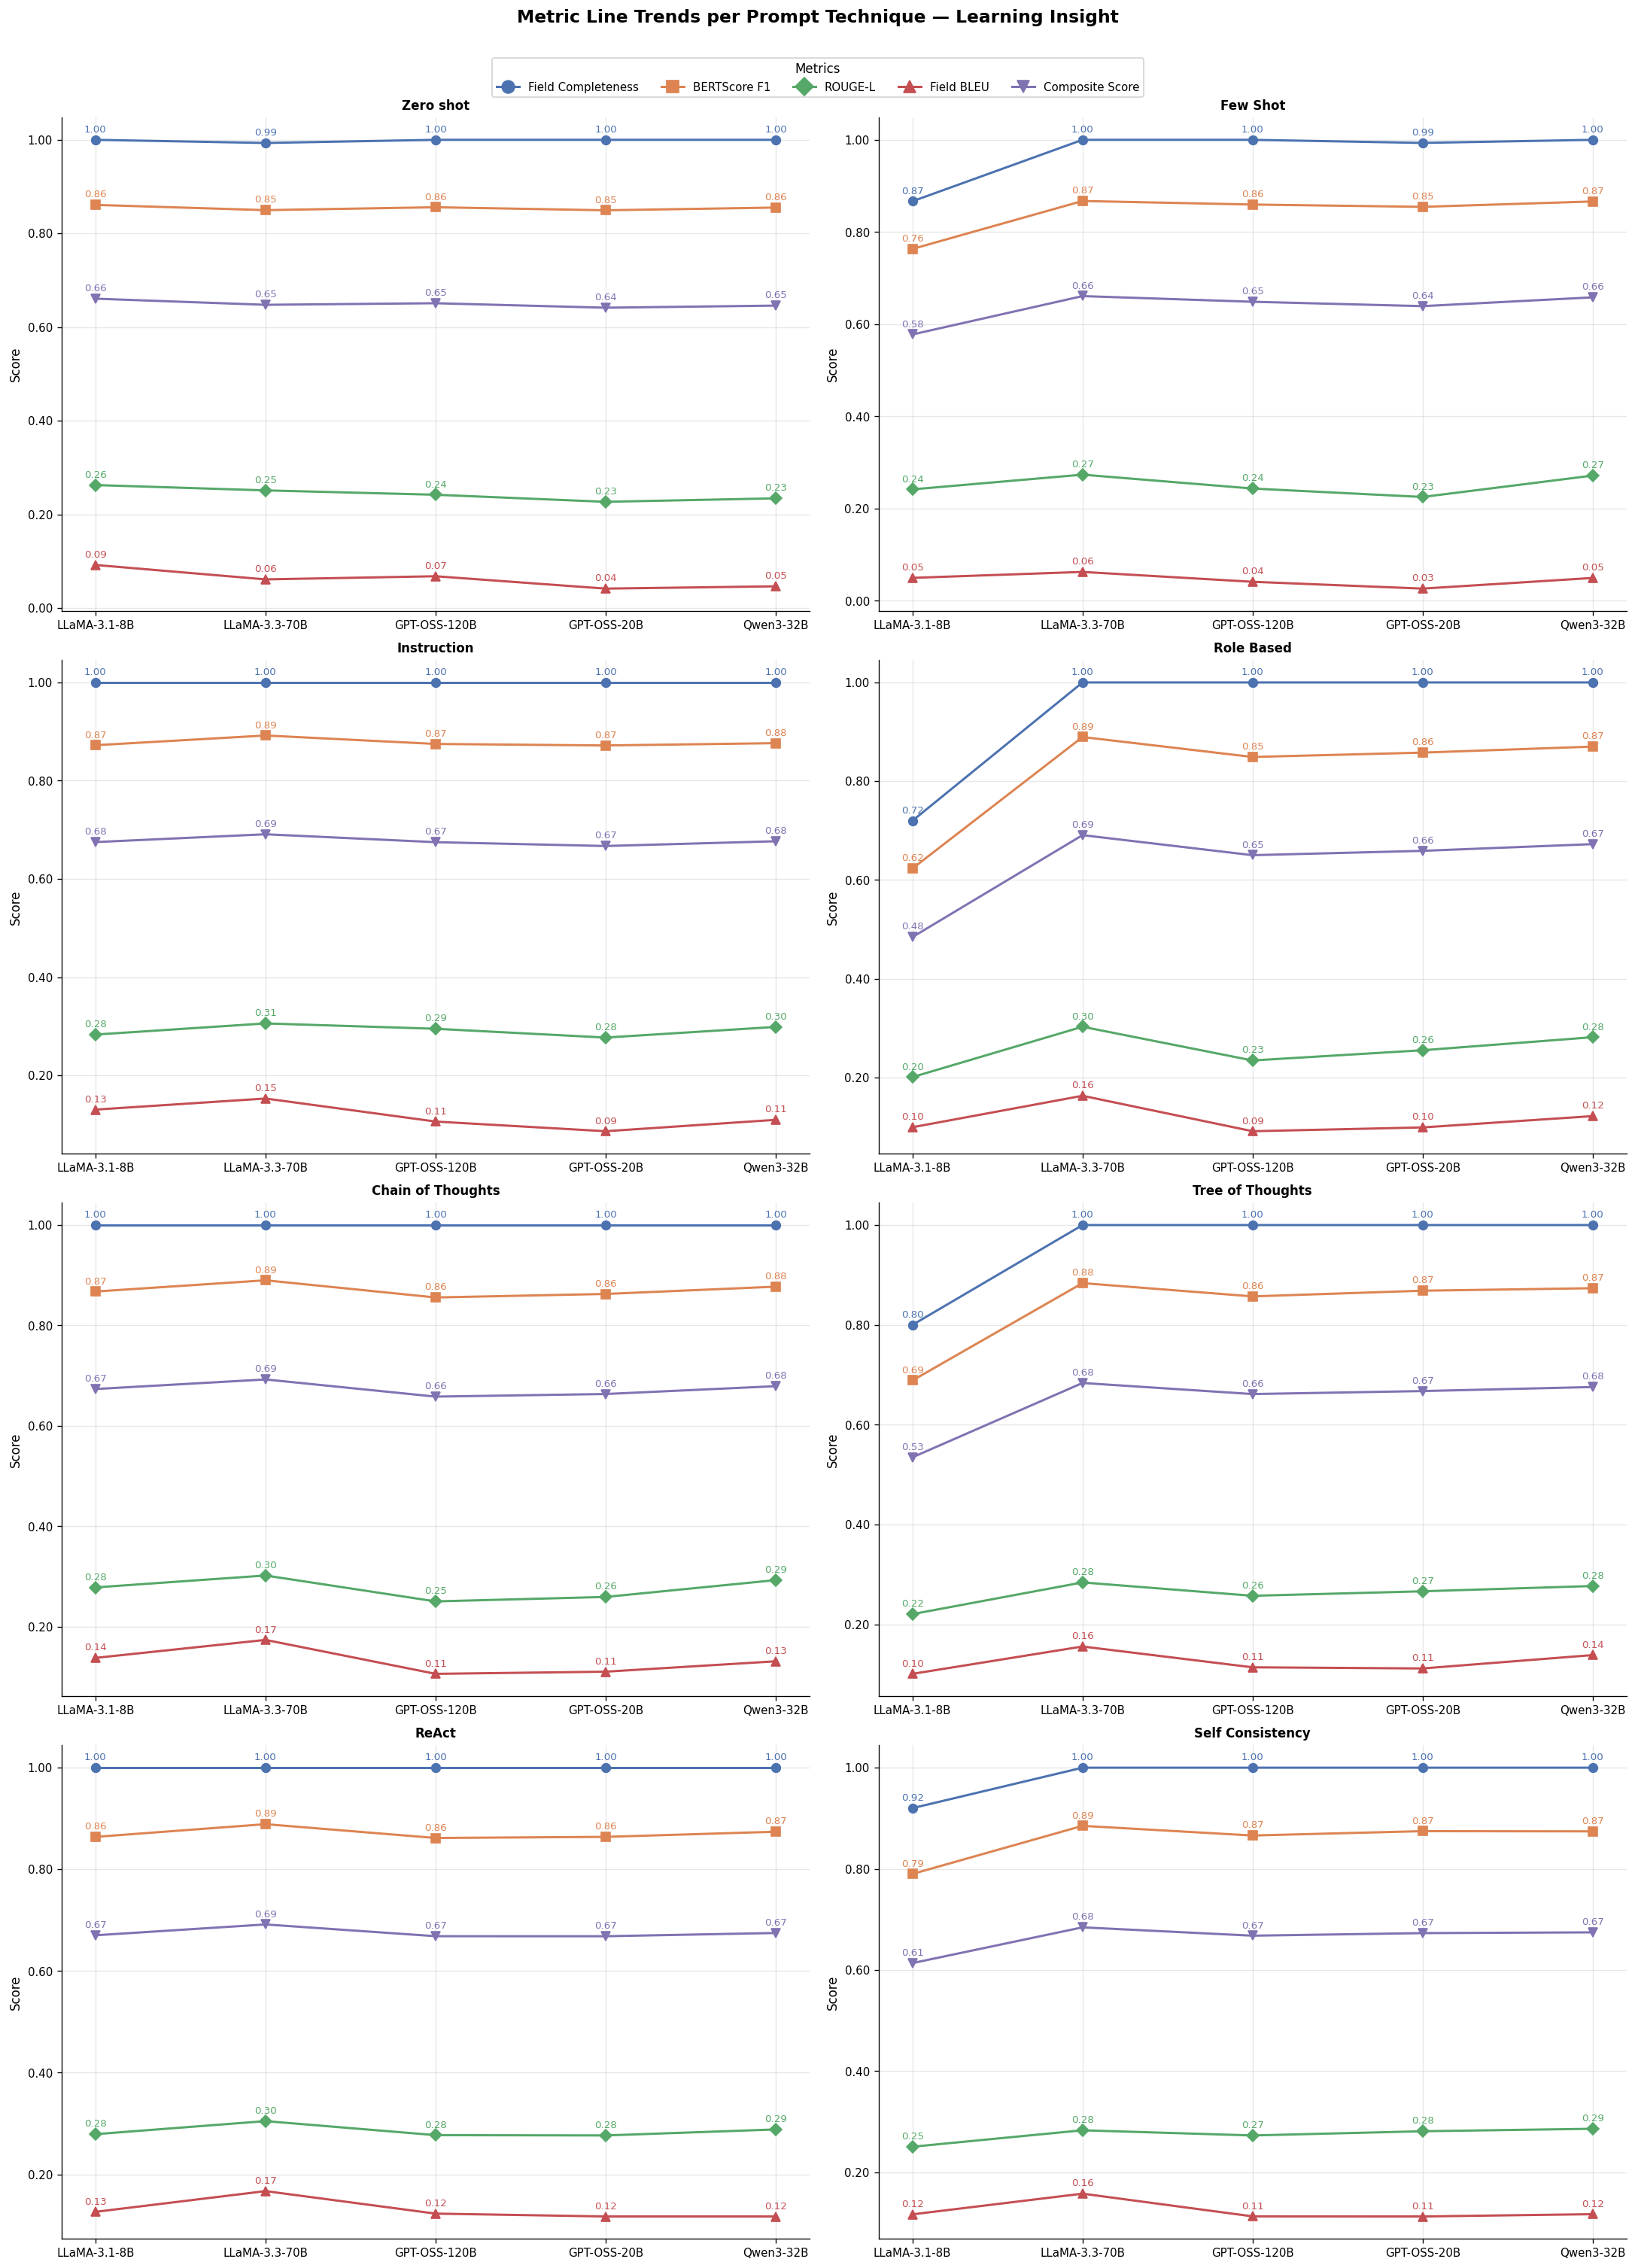

In [ ]:
MARKERS = ["o", "s", "D", "^", "v"]


def plot_prompt_line(ax, data, prompt, metrics):
    """X-axis = Models, one line per metric, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg    = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    x = np.arange(len(MODELS))
    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        ax.plot(
            x, vals,
            marker=MARKERS[i % len(MARKERS)],
            label=METRIC_LABELS.get(metric, metric),
            color=color, linewidth=1.8, markersize=7,
        )
        for xi, val in zip(x, vals):
            if not np.isnan(val):
                ax.annotate(
                    f"{val:.2f}", (xi, val),
                    textcoords="offset points", xytext=(0, 6),
                    ha="center", fontsize=8, color=color,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=9, ha="center")
    ax.set_ylabel("Score", fontsize=10)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_line(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

line_handles = [
    Line2D([0], [0], color=METRIC_COLORS[i], marker=MARKERS[i % len(MARKERS)],
           linewidth=1.8, markersize=10)
    for i in range(len(metrics_to_plot))
]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(
    line_handles, metric_names, loc="upper center",
    ncol=len(metrics_to_plot), fontsize=9,
    bbox_to_anchor=(0.5, 1.02), frameon=True,
    title="Metrics", title_fontsize=10,
)
fig.suptitle(
    "Metric Line Trends per Prompt Technique — Learning Insight",
    fontsize=14, fontweight="bold", y=1.04,
)
plt.savefig("li_line_per_prompt.png", bbox_inches="tight")
plt.show()

## 5. Radar Charts: Latency Profile per Model across Prompt Techniques

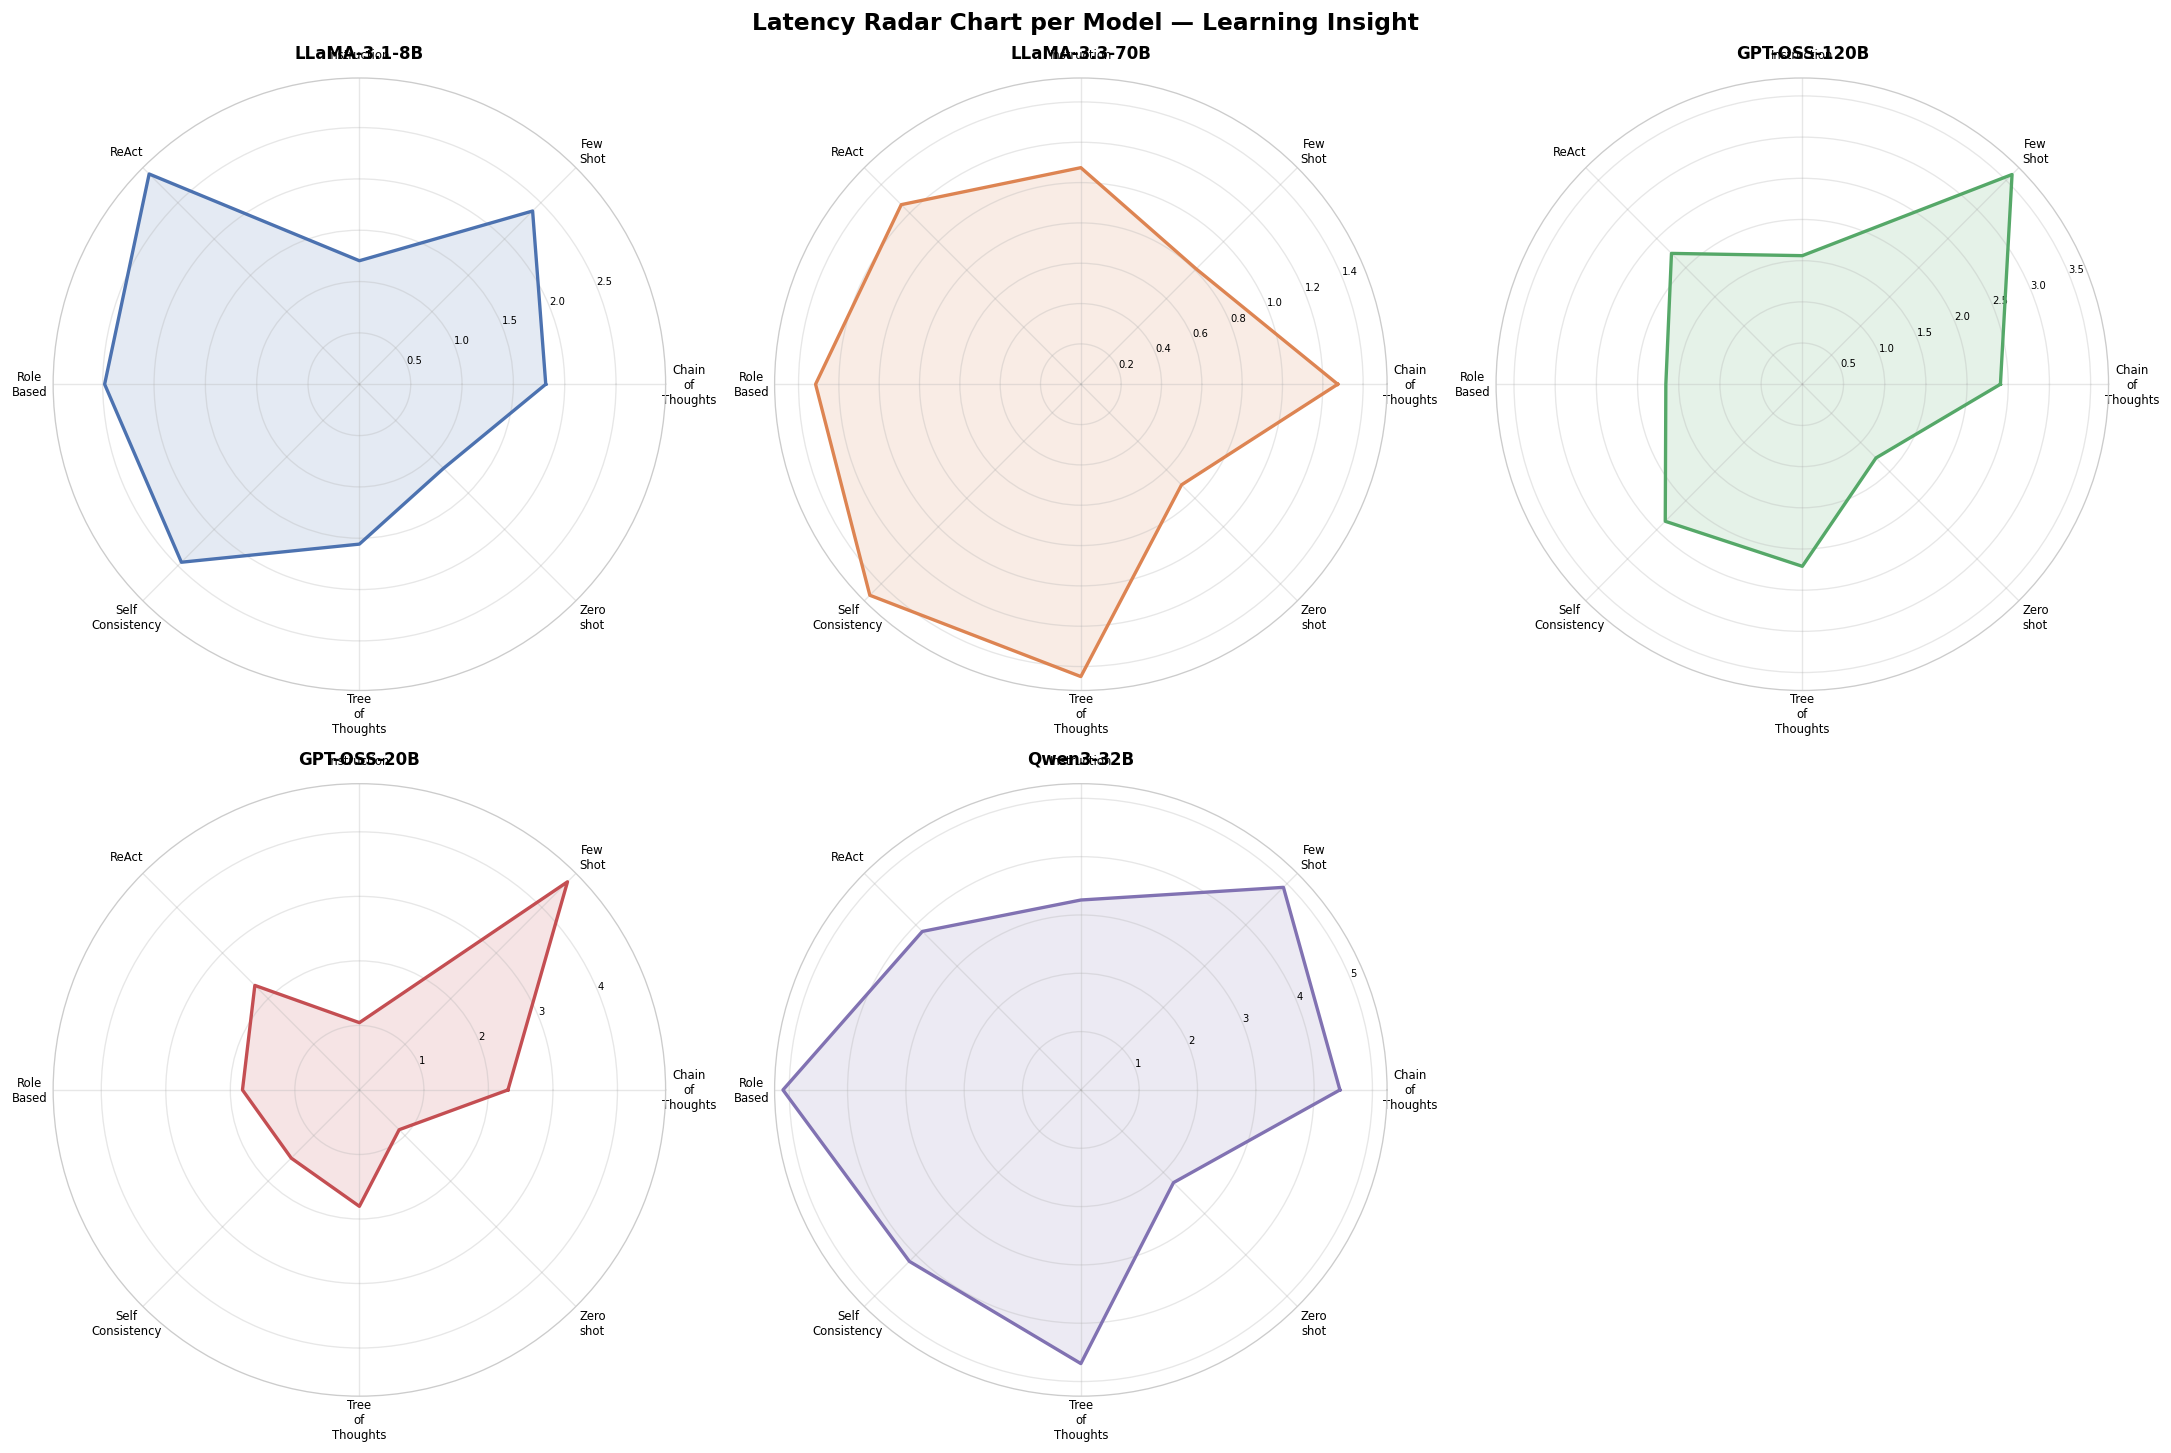

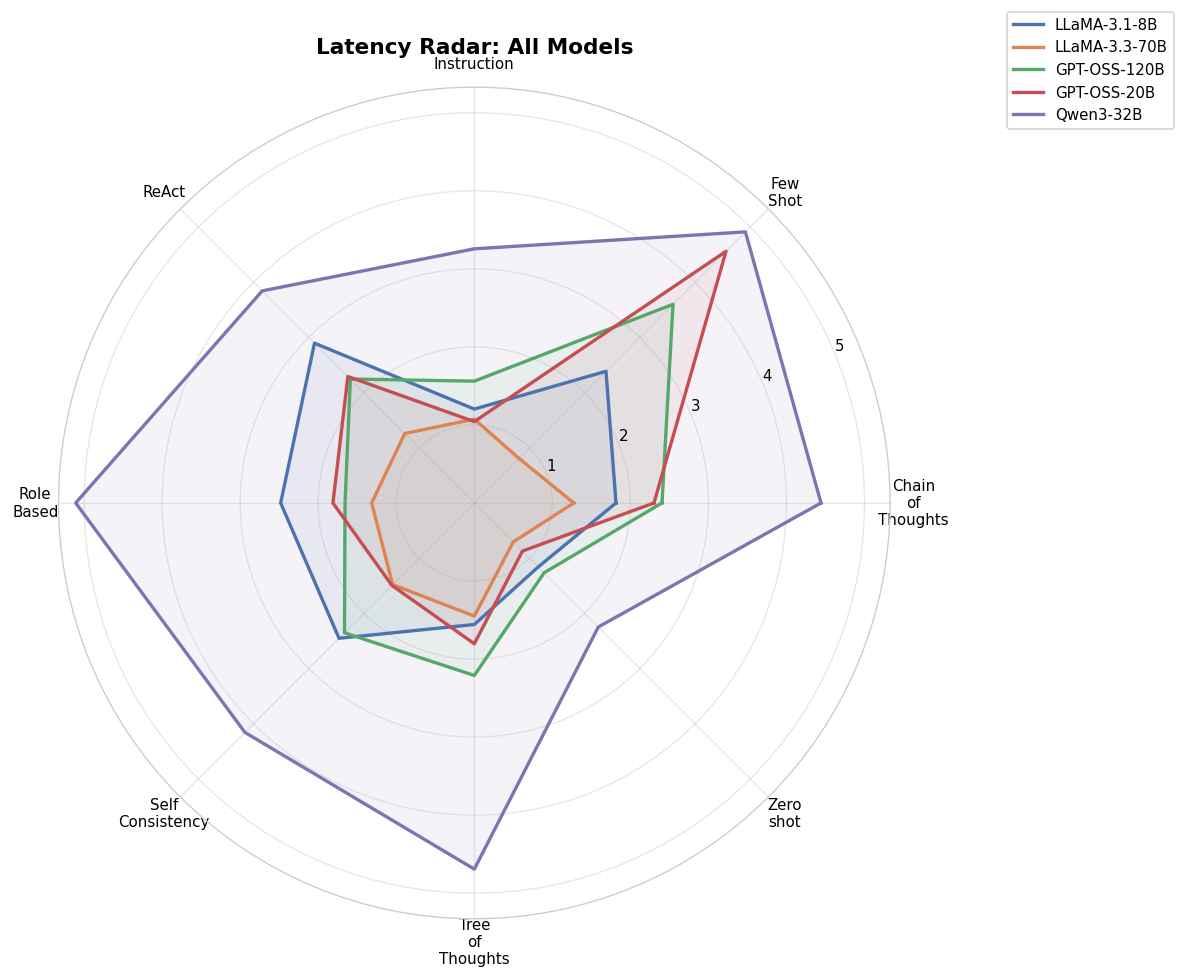

In [ ]:
def make_radar_chart(ax, values, labels, color, model_name, fill_alpha=0.15):
    """Draw a single radar (spider) chart on a polar axis."""
    n             = len(labels)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]

    ax.plot(angles_closed, values_closed, color=color, linewidth=2)
    ax.fill(angles_closed, values_closed, color=color, alpha=fill_alpha)
    ax.set_xticks(angles)
    ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in labels], size=7)
    ax.set_title(model_name, size=10, fontweight="bold", pad=12)
    ax.spines["polar"].set_color("#cccccc")
    ax.yaxis.set_tick_params(labelsize=6)


pivot = (
    df.groupby(["Prompting", "Model"])["avg_latency_sec"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
prompt_labels = pivot.index.tolist()

# Individual radar per model
n_cols = 3
n_rows = int(np.ceil(len(MODELS) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(18, 6 * n_rows),
    subplot_kw={"polar": True}, constrained_layout=True,
)
axes = np.array(axes).flatten()

for i, model in enumerate(MODELS):
    vals  = pivot[model].fillna(0).tolist()
    color = MODEL_COLORS.get(model, "#888888")
    make_radar_chart(axes[i], vals, prompt_labels, color, model)

for idx in range(len(MODELS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Latency Radar Chart per Model — Learning Insight", fontsize=14, fontweight="bold")
plt.savefig("li_radar_latency.png", bbox_inches="tight")
plt.show()


# Combined radar — all models overlaid
n             = len(prompt_labels)
angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
for model in MODELS:
    vals        = pivot[model].fillna(0).tolist()
    vals_closed = vals + [vals[0]]
    color       = MODEL_COLORS.get(model, "#888888")
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2, label=model)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.08)

ax.set_xticks(angles)
ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in prompt_labels], size=9)
ax.spines["polar"].set_color("#cccccc")
ax.set_title("Latency Radar: All Models", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.savefig("li_radar_latency_combined.png", bbox_inches="tight")
plt.show()

## 6. Overall Quality Metrics per Prompt Technique

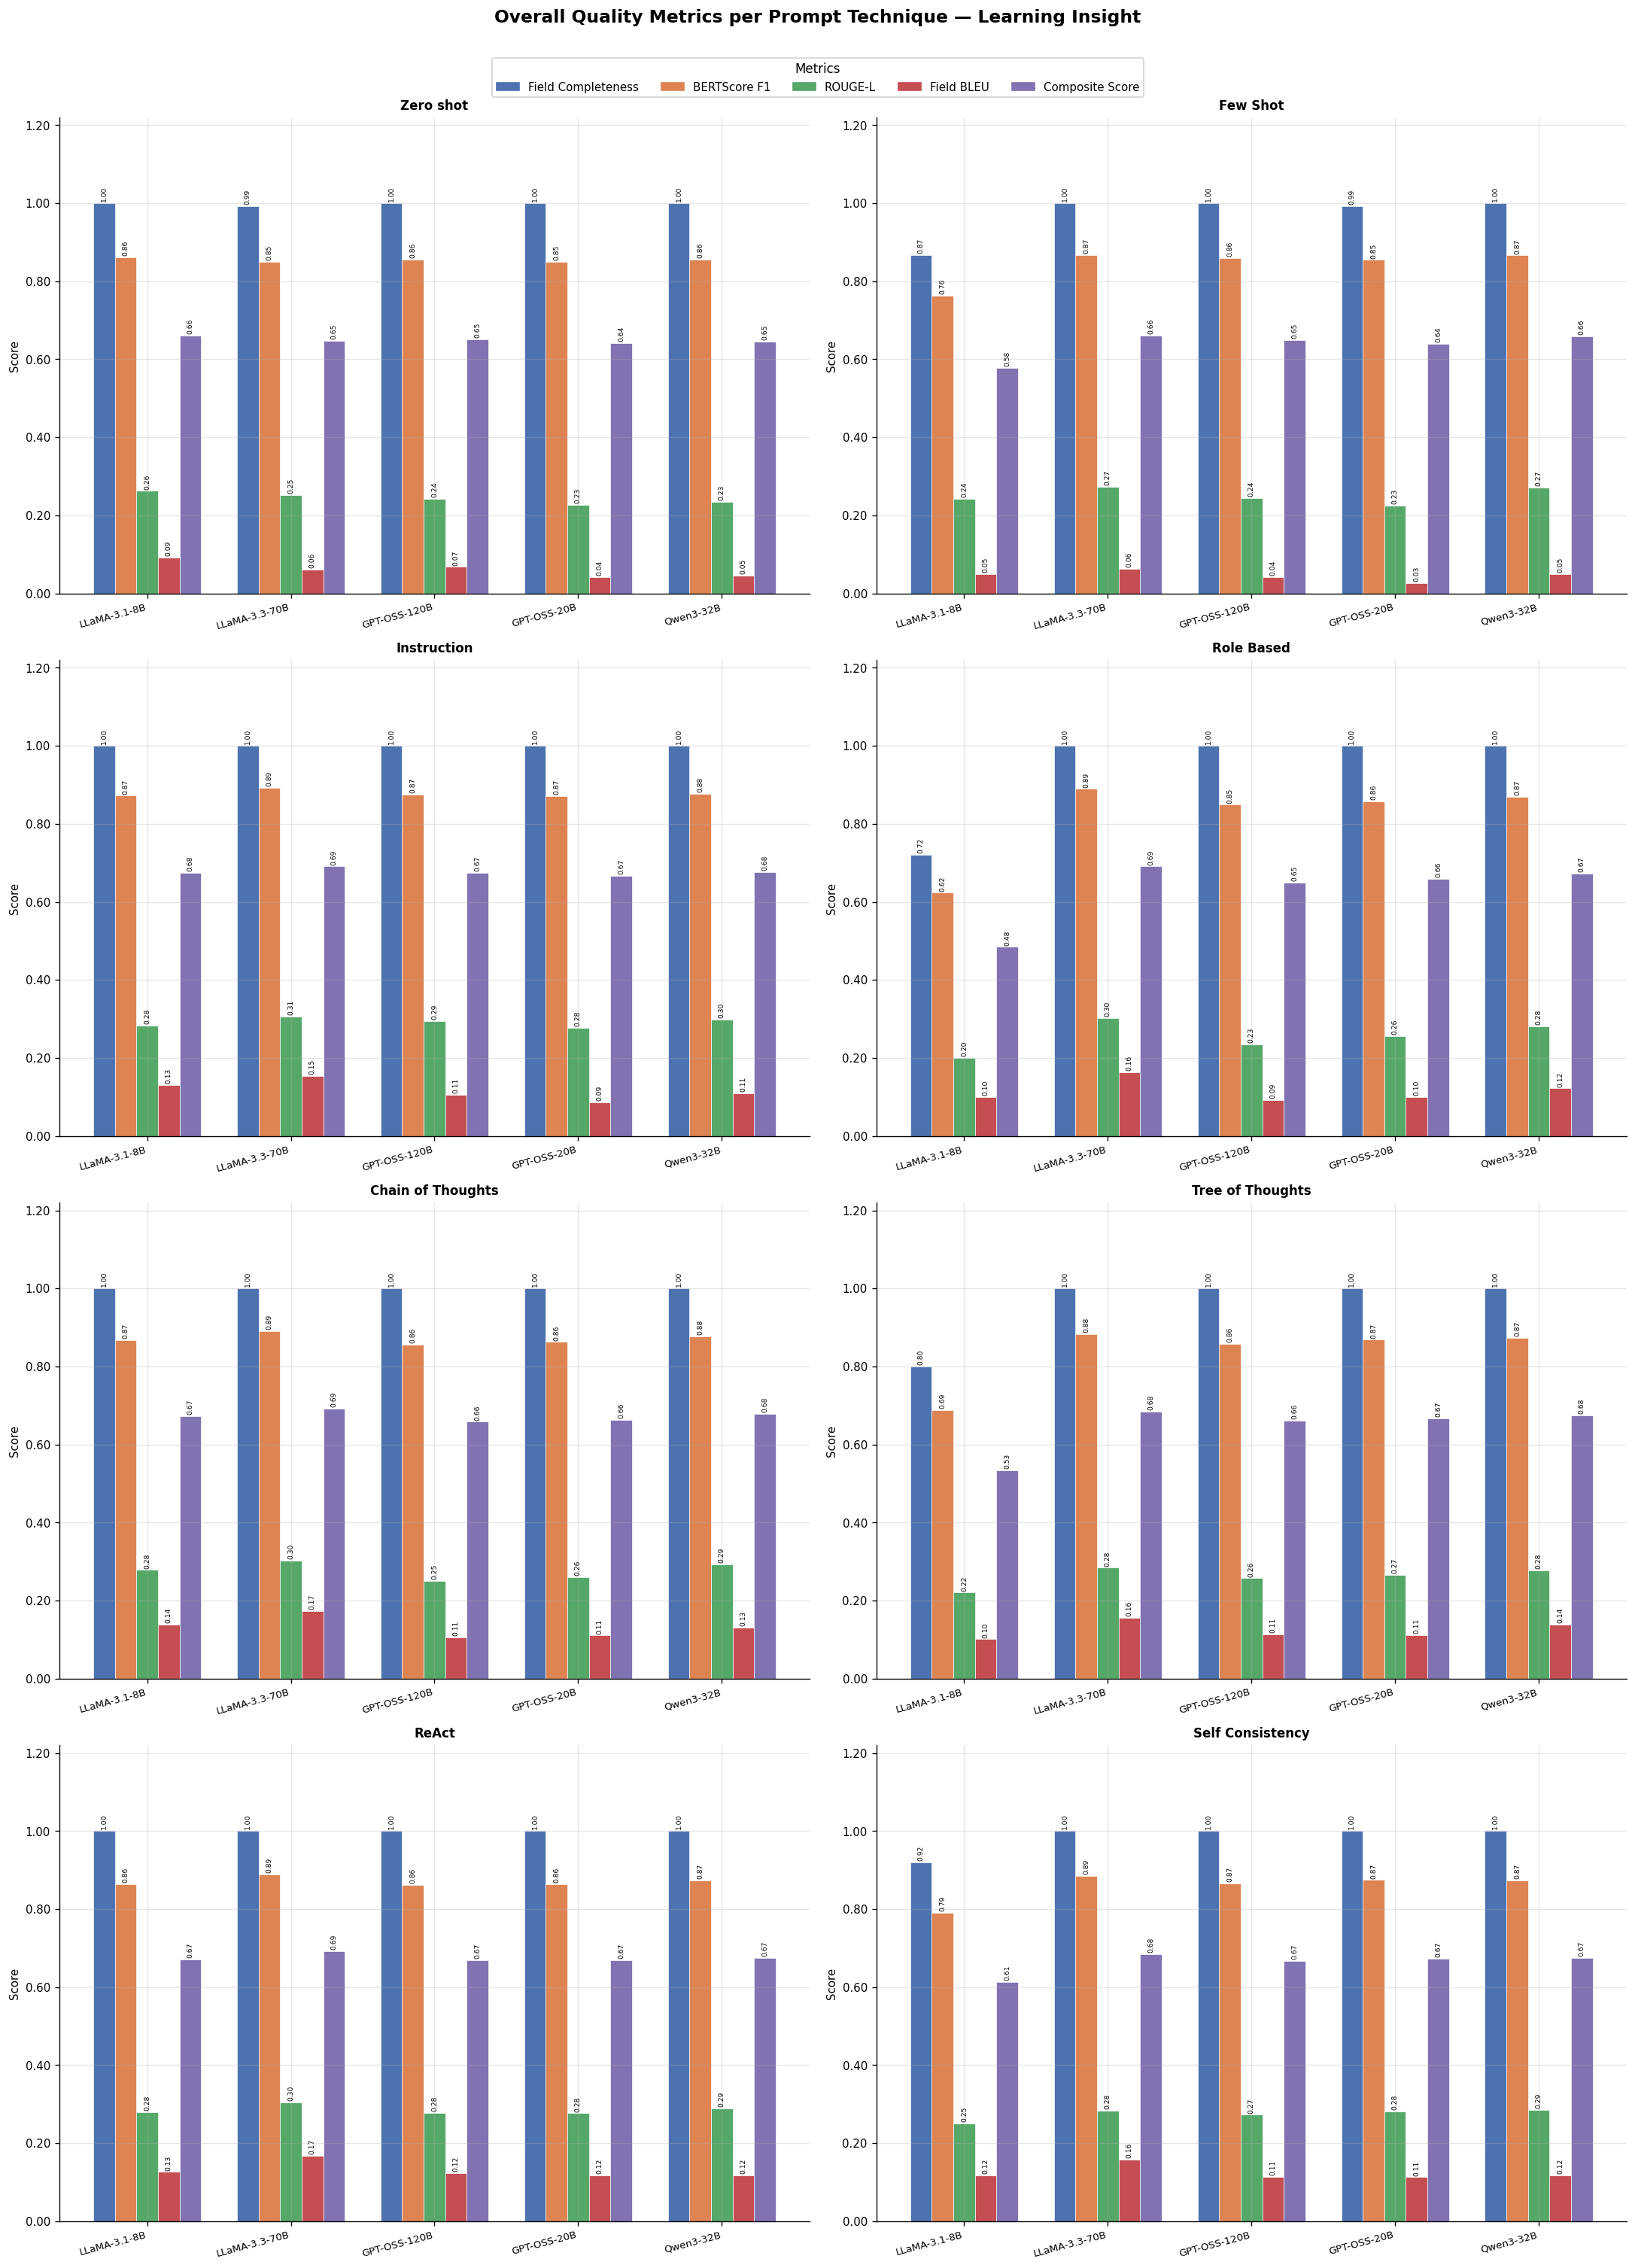

In [ ]:
metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    ax     = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg    = subset.groupby("Model")[metrics_to_plot].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics_to_plot)
    x       = np.arange(n_models)
    bar_w   = 0.75 / n_metrics
    offsets = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics_to_plot, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(
            x + offsets[i], vals, width=bar_w,
            label=METRIC_LABELS.get(metric, metric),
            color=color, edgecolor="white", linewidth=0.4,
        )
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=5.5, rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics_to_plot].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [
    plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
    for i in range(len(metrics_to_plot))
]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(
    metric_handles, metric_names, loc="upper center",
    ncol=len(metrics_to_plot), fontsize=9,
    bbox_to_anchor=(0.5, 1.02), frameon=True,
    title="Metrics", title_fontsize=10,
)
fig.suptitle(
    "Overall Quality Metrics per Prompt Technique — Learning Insight",
    fontsize=14, fontweight="bold", y=1.04,
)
plt.savefig("li_overall_quality_bar.png", bbox_inches="tight")
plt.show()

## 7. Composite Score Heatmap: Model x Prompt

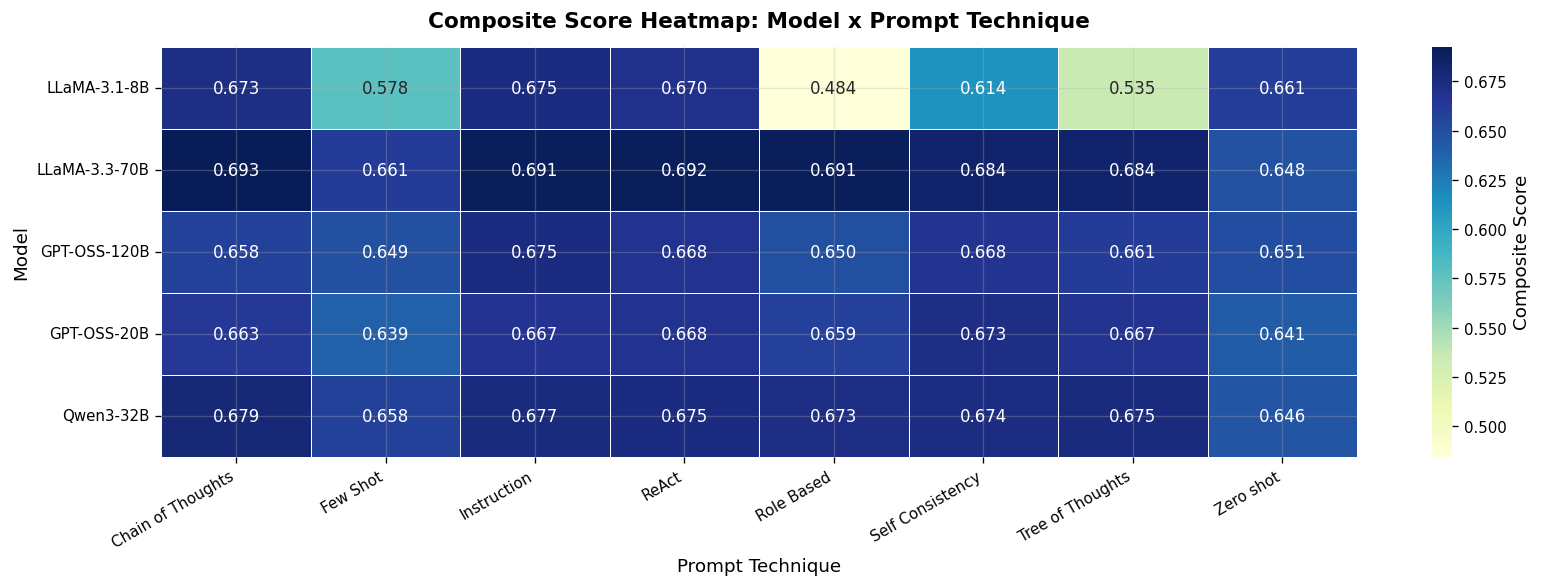

In [ ]:
comp_pivot = (
    df.groupby(["Model", "Prompting"])["composite_score"]
    .mean()
    .unstack("Prompting")
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    comp_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Composite Score"},
)
ax.set_title(
    "Composite Score Heatmap: Model x Prompt Technique",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Prompt Technique", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("li_composite_heatmap.png", bbox_inches="tight")
plt.show()

## 8. Field Completeness Heatmap: Model x Prompt

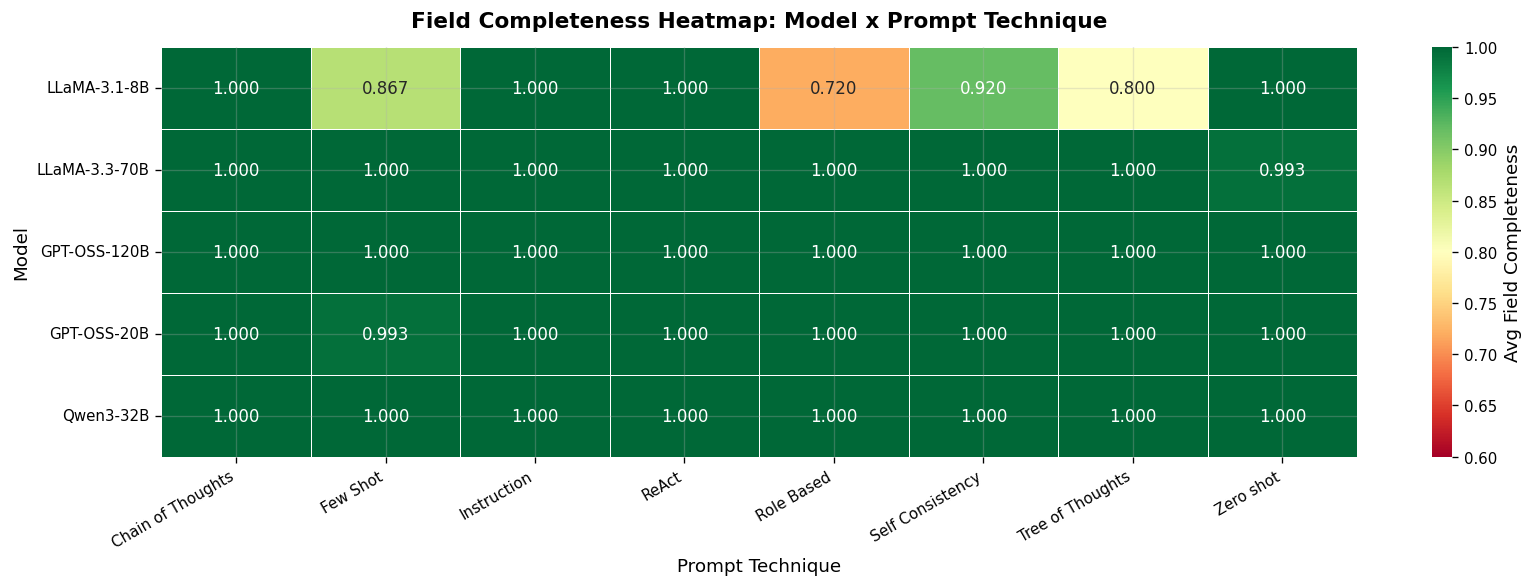

In [ ]:
fc_pivot = (
    df.groupby(["Model", "Prompting"])["avg_field_completeness"]
    .mean()
    .unstack("Prompting")
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    fc_pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    linewidths=0.5,
    vmin=0.6,
    vmax=1.0,
    ax=ax,
    cbar_kws={"label": "Avg Field Completeness"},
)
ax.set_title(
    "Field Completeness Heatmap: Model x Prompt Technique",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Prompt Technique", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("li_field_completeness_heatmap.png", bbox_inches="tight")
plt.show()

## 9. Box Plots: Distribution of Composite Score and Latency

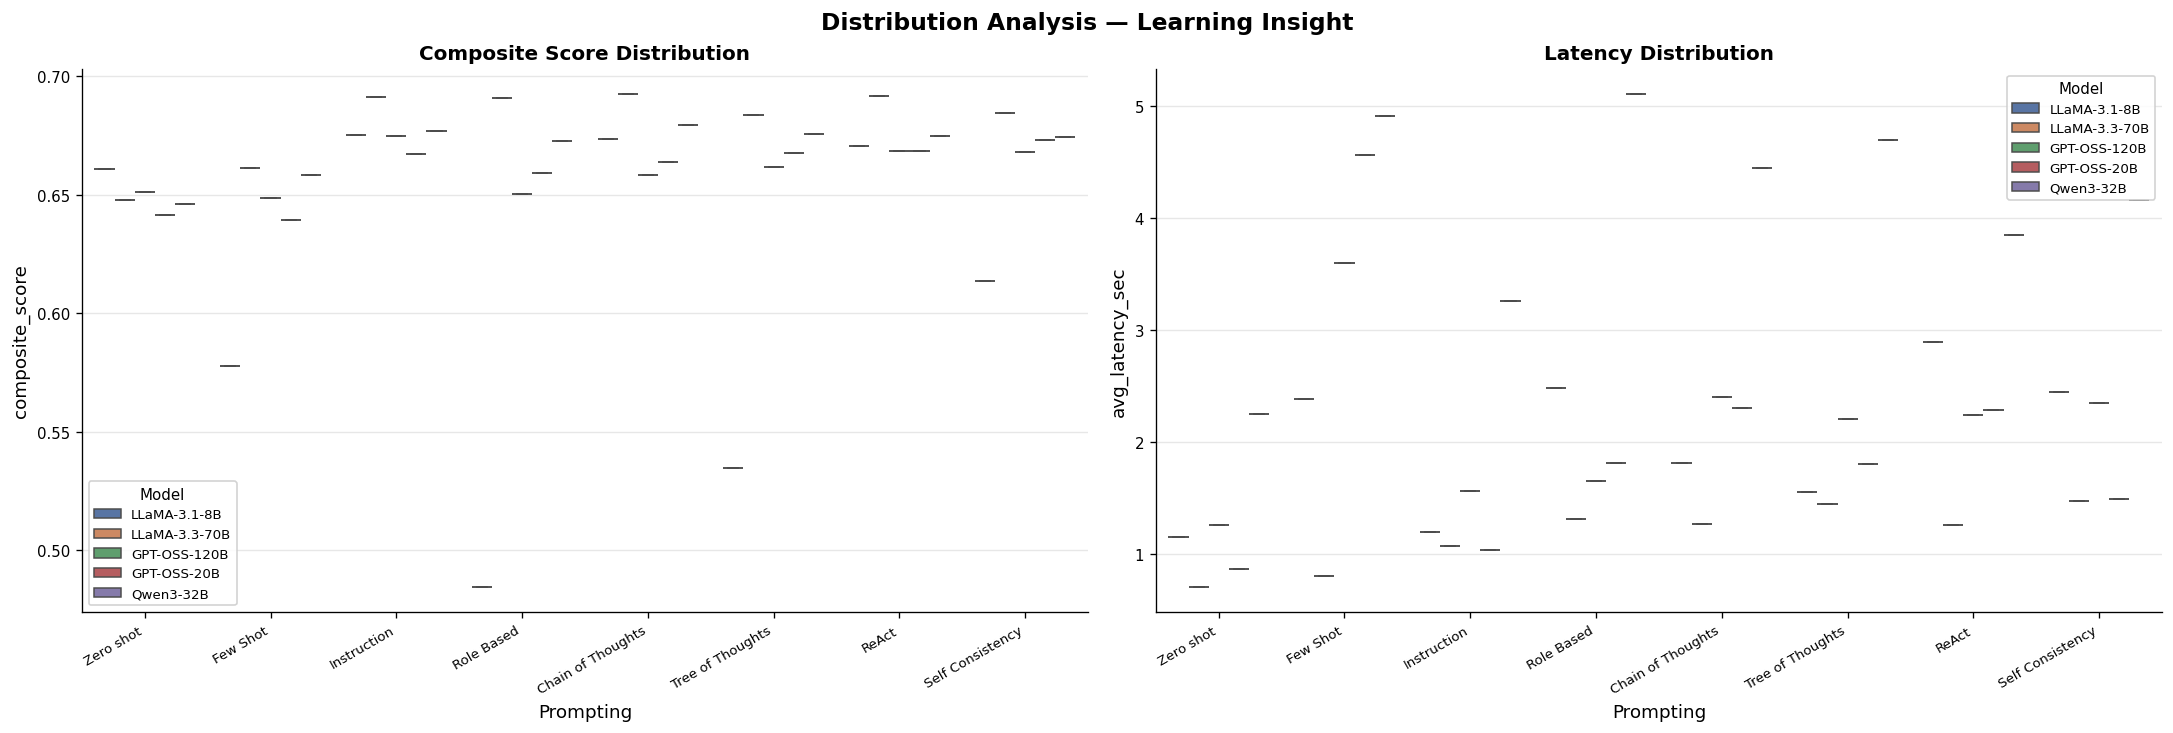

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.boxplot(
    data=df, x="Prompting", y="composite_score", hue="Model",
    palette=MODEL_COLORS, ax=axes[0], linewidth=0.9, fliersize=3,
)
axes[0].set_title("Composite Score Distribution", fontsize=12, fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[0].legend(title="Model", fontsize=8, title_fontsize=9)

sns.boxplot(
    data=df, x="Prompting", y="avg_latency_sec", hue="Model",
    palette=MODEL_COLORS, ax=axes[1], linewidth=0.9, fliersize=3,
)
axes[1].set_title("Latency Distribution", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[1].legend(title="Model", fontsize=8, title_fontsize=9)

fig.suptitle(
    "Distribution Analysis — Learning Insight",
    fontsize=14, fontweight="bold",
)
plt.savefig("li_boxplot.png", bbox_inches="tight")
plt.show()

## 10. BERTScore F1 and ROUGE-L Side-by-Side

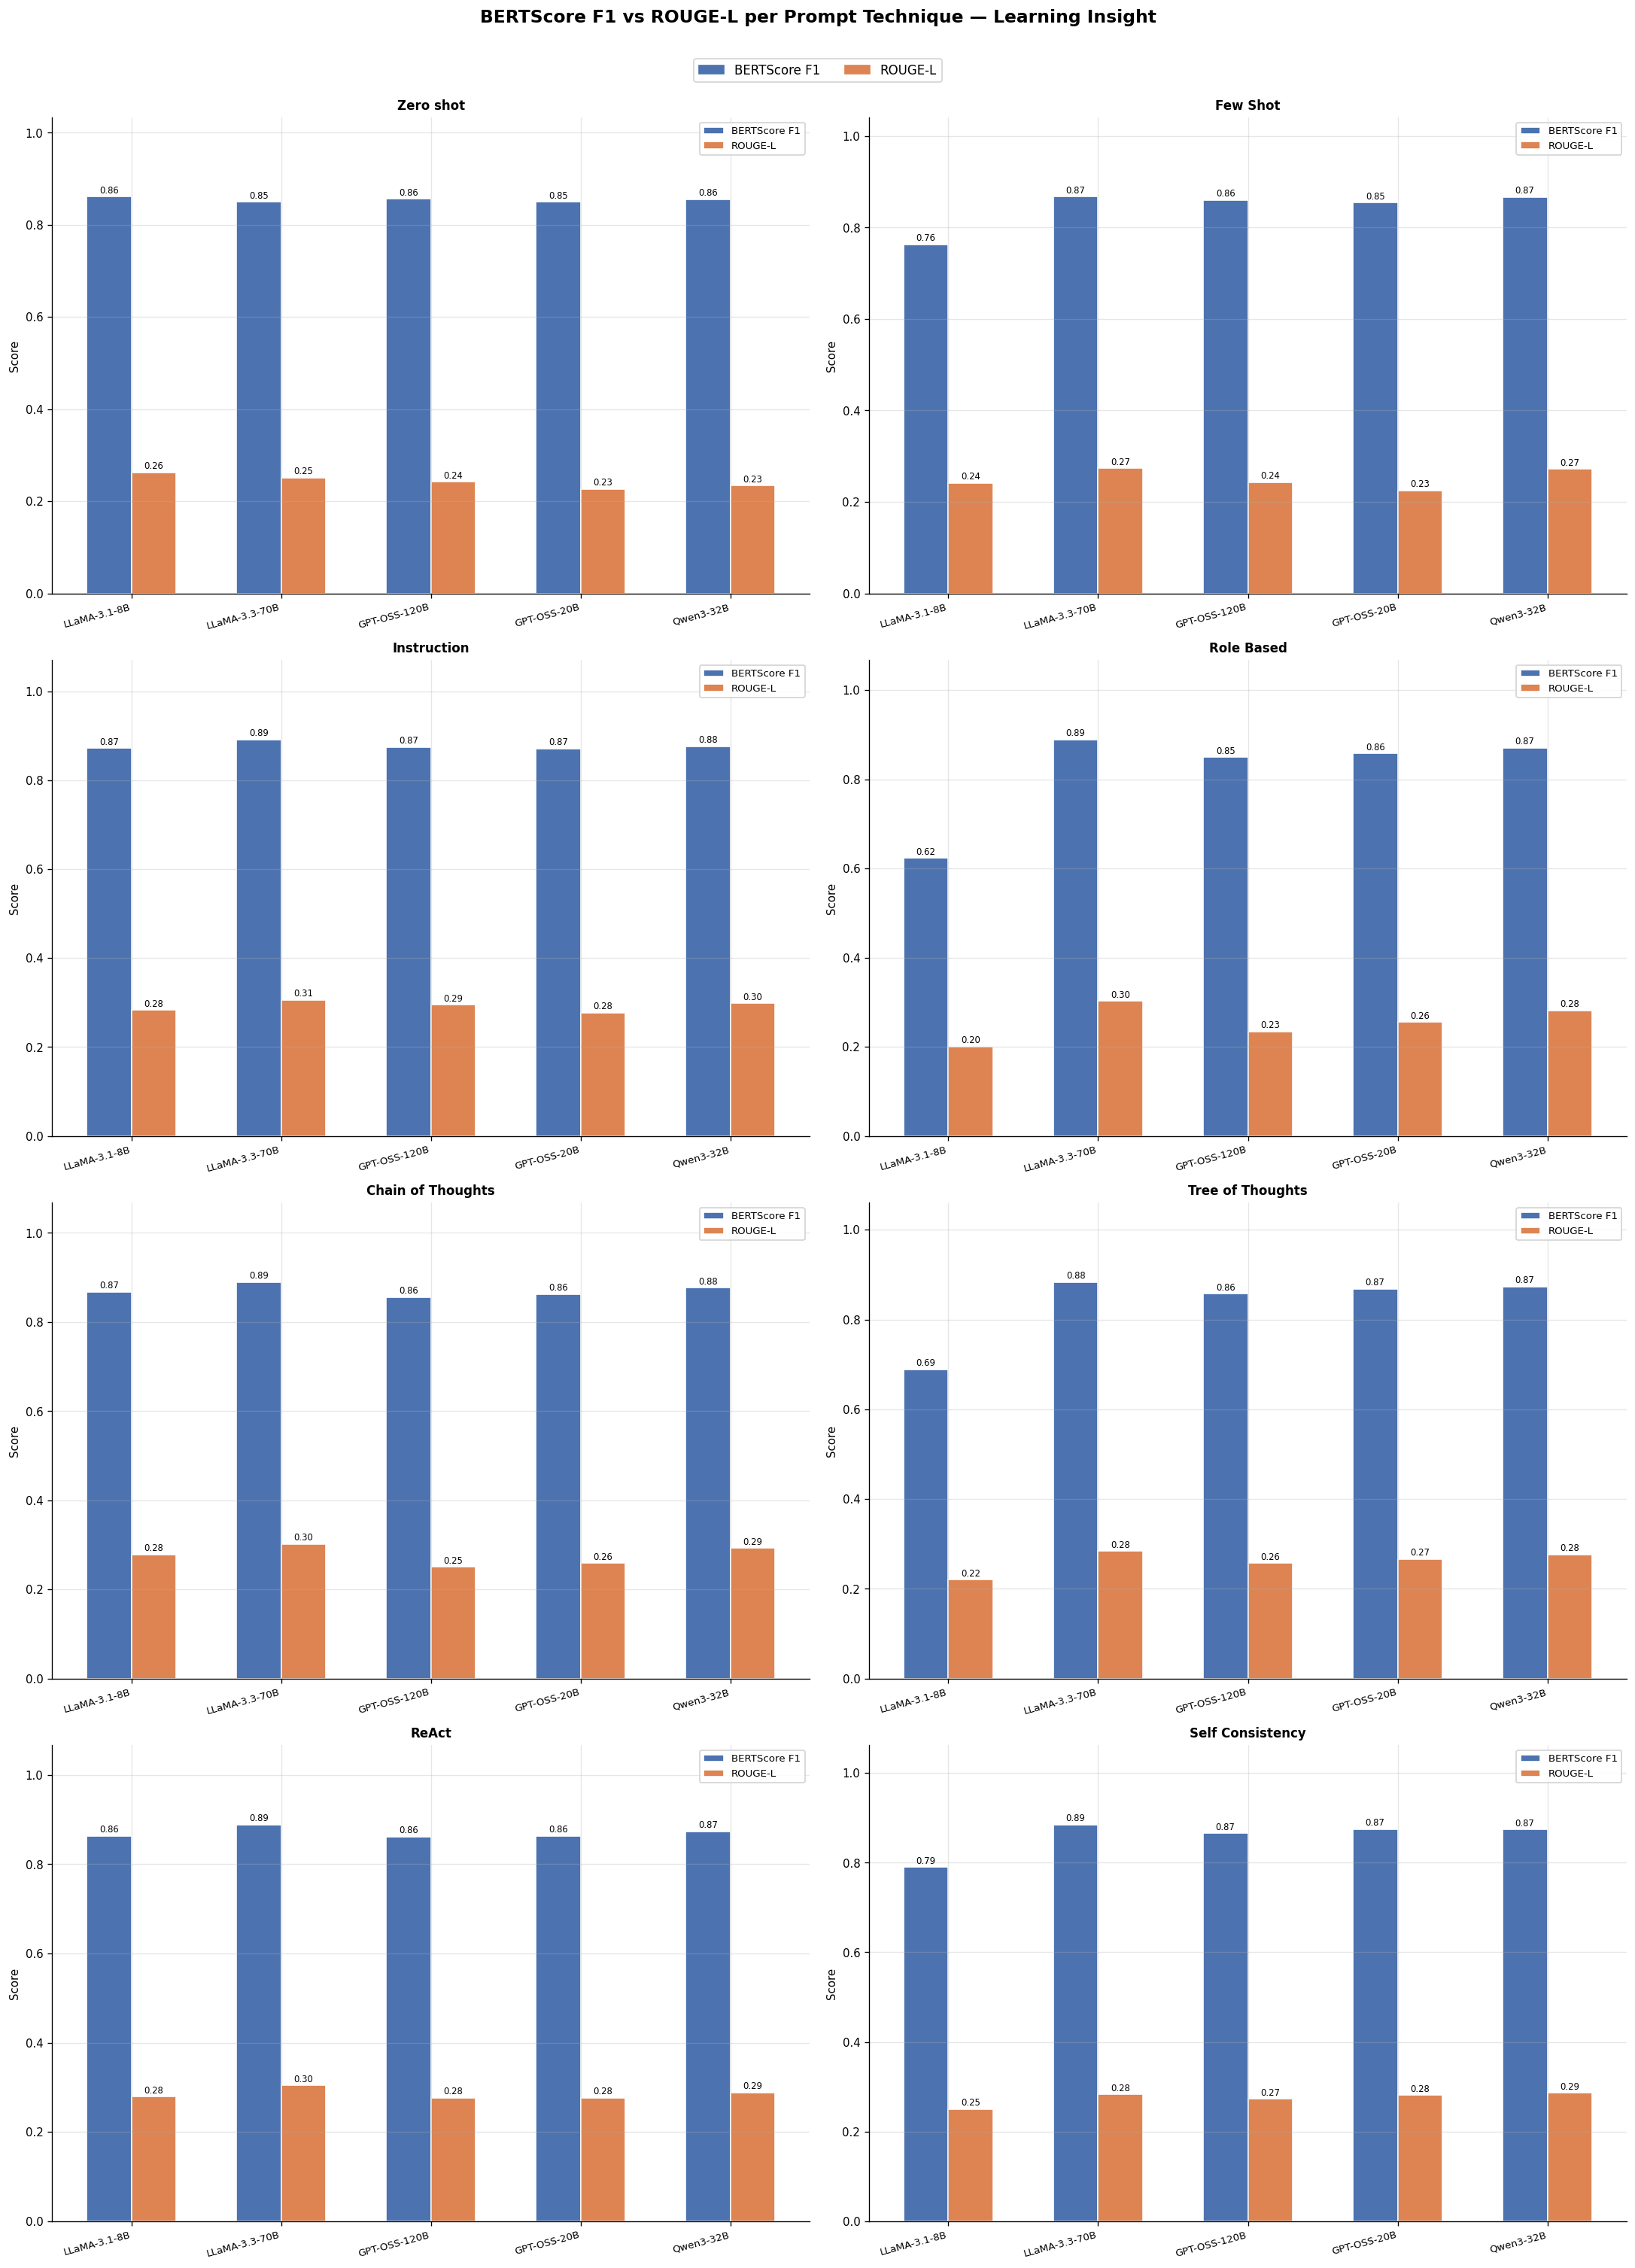

In [ ]:
nlp_metrics  = ["avg_bert_f1", "avg_rouge_l"]
nlp_colors   = ["#4C72B0", "#DD8452"]

n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    ax     = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg    = subset.groupby("Model")[nlp_metrics].mean().reindex(MODELS)
    x      = np.arange(len(MODELS))
    bar_w  = 0.30
    offsets = np.array([-0.5, 0.5]) * bar_w

    for i, (metric, color) in enumerate(zip(nlp_metrics, nlp_colors)):
        vals = agg[metric].values
        bars = ax.bar(
            x + offsets[i], vals, width=bar_w,
            label=METRIC_LABELS.get(metric, metric),
            color=color, edgecolor="white",
        )
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f"{val:.2f}",
                    ha="center", va="bottom", fontsize=7,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    valid_max = agg[nlp_metrics].max().max()
    ax.set_ylim(0, valid_max * 1.2 if not np.isnan(valid_max) else 1)
    ax.legend(fontsize=8)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in nlp_colors]
names   = [METRIC_LABELS.get(m, m) for m in nlp_metrics]
fig.legend(
    handles, names, loc="upper center", ncol=2,
    fontsize=10, bbox_to_anchor=(0.5, 1.02), frameon=True,
)
fig.suptitle(
    "BERTScore F1 vs ROUGE-L per Prompt Technique — Learning Insight",
    fontsize=14, fontweight="bold", y=1.04,
)
plt.savefig("li_bert_rouge_per_prompt.png", bbox_inches="tight")
plt.show()

## 11. Best Model per Metric (Composite Score)

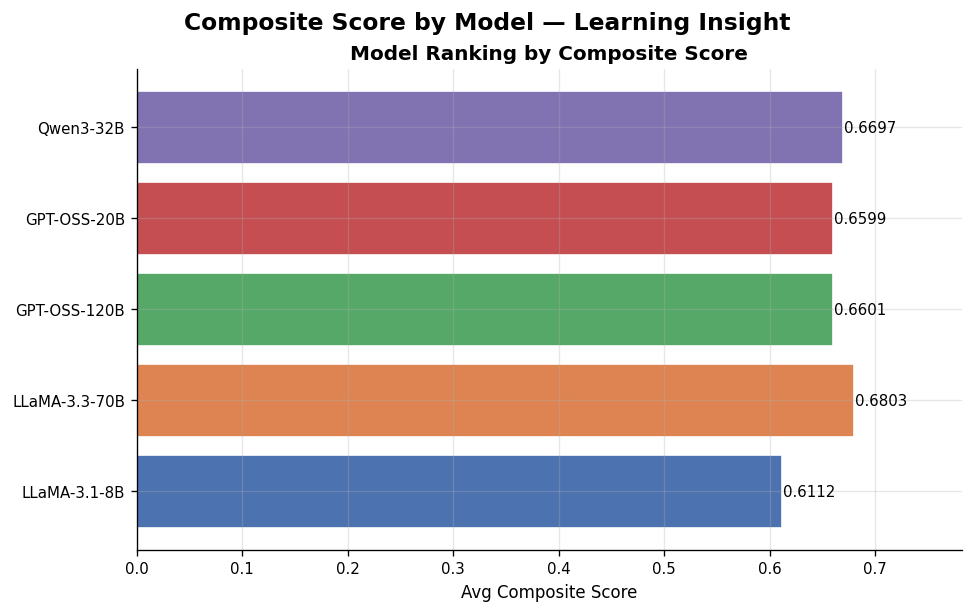

In [ ]:
model_scores = (
    df.groupby("Model")["composite_score"]
    .mean()
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bar_colors = [MODEL_COLORS.get(m, "gray") for m in model_scores.index]
bars = ax.barh(
    model_scores.index,
    model_scores.values,
    color=bar_colors,
    edgecolor="white",
)
for bar, val in zip(bars, model_scores.values):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=9,
    )
ax.set_title("Model Ranking by Composite Score", fontsize=12, fontweight="bold")
ax.set_xlabel("Avg Composite Score", fontsize=10)
ax.set_xlim(0, model_scores.max() * 1.15)
fig.suptitle(
    "Composite Score by Model — Learning Insight",
    fontsize=14, fontweight="bold",
)
plt.savefig("li_model_composite.png", bbox_inches="tight")
plt.show()

## 12. Latency Breakdown: Min / Avg / Max per Model

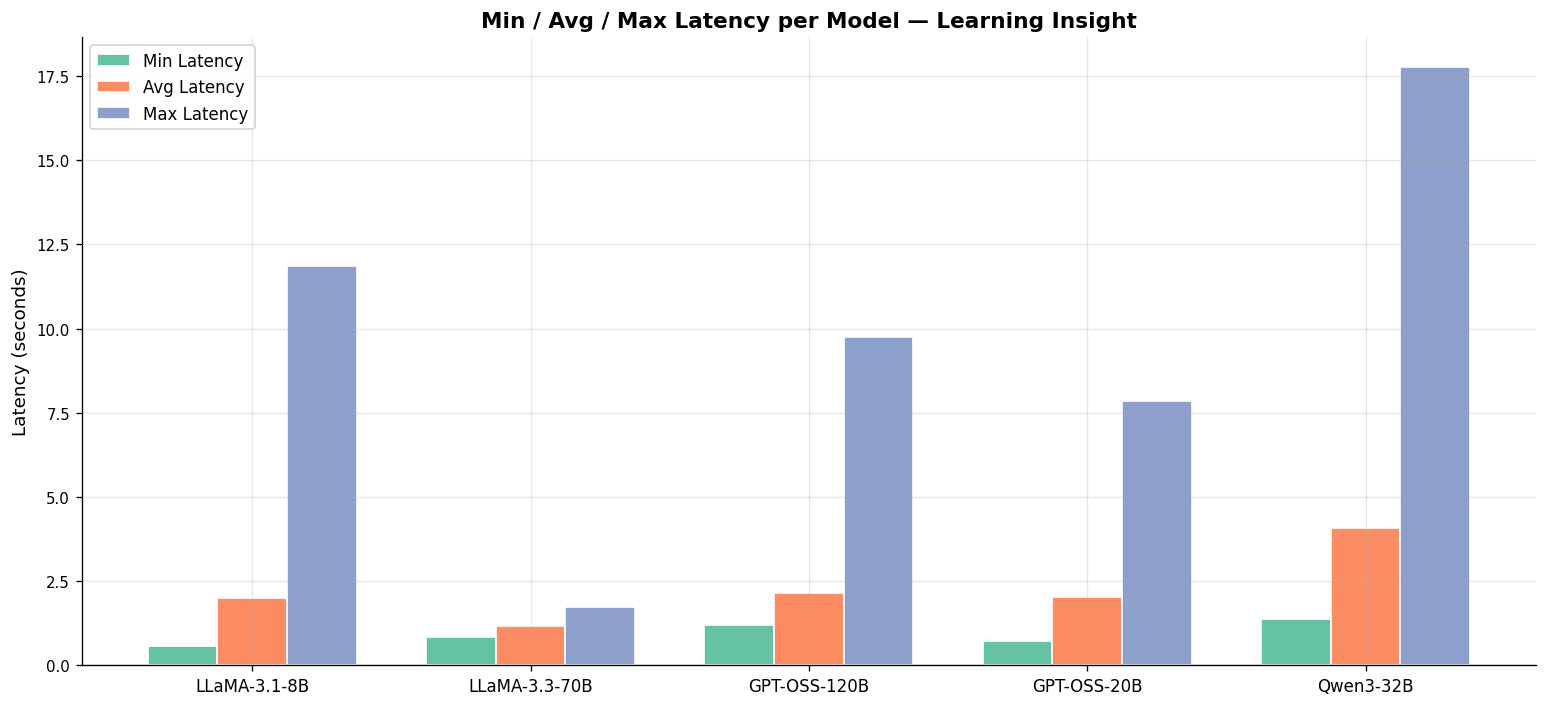

In [ ]:
lat_agg = (
    df.groupby("Model")[["min_latency_sec", "avg_latency_sec", "max_latency_sec"]]
    .mean()
    .reindex(MODELS)
)

x             = np.arange(len(MODELS))
width         = 0.25
lat_bar_colors = ["#66C2A5", "#FC8D62", "#8DA0CB"]
lat_labels_map = ["Min Latency", "Avg Latency", "Max Latency"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color, label) in enumerate(zip(
    ["min_latency_sec", "avg_latency_sec", "max_latency_sec"],
    lat_bar_colors,
    lat_labels_map,
)):
    ax.bar(
        x + (i - 1) * width, lat_agg[col].values,
        width=width, label=label, color=color, edgecolor="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylabel("Latency (seconds)", fontsize=11)
ax.set_title(
    "Min / Avg / Max Latency per Model — Learning Insight",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("li_latency_breakdown.png", bbox_inches="tight")
plt.show()

## 13. Correlation Heatmap: All Metrics

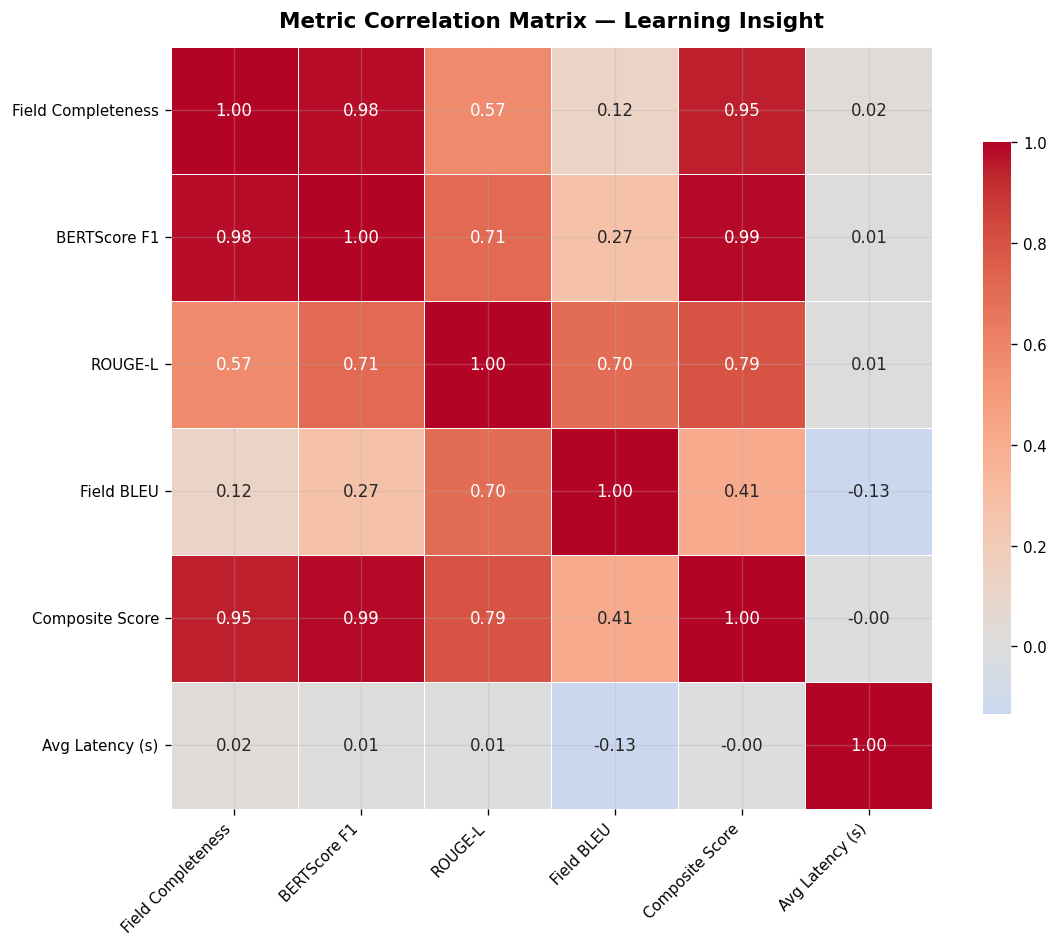

In [ ]:
all_metrics = QUALITY_METRICS + ["avg_latency_sec"]
available   = [m for m in all_metrics if df[m].notna().sum() > 10]

corr_matrix = df[available].corr()
labels      = [METRIC_LABELS.get(m, m) for m in available]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"shrink": 0.75},
)
ax.set_title(
    "Metric Correlation Matrix — Learning Insight",
    fontsize=13, fontweight="bold", pad=12,
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("li_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 14. Rankings: Top Models and Prompt Techniques

In [ ]:
ranking_metrics   = ["composite_score", "avg_bert_f1", "avg_rouge_l", "avg_field_completeness", "avg_latency_sec"]
available_ranking = [m for m in ranking_metrics if df[m].notna().sum() > 0]
agg_ascending     = {m: (m == "avg_latency_sec") for m in available_ranking}

print("=" * 80)
print("MODEL RANKINGS (mean across all prompts)")
print("=" * 80)
model_rank = df.groupby("Model")[available_ranking].mean().round(4)
for metric in available_ranking:
    model_rank[f"Rank_{metric}"] = model_rank[metric].rank(
        ascending=agg_ascending[metric]
    ).astype(int)
print(model_rank.to_string())

print("\n" + "=" * 80)
print("PROMPT TECHNIQUE RANKINGS (mean across all models)")
print("=" * 80)
prompt_rank = df.groupby("Prompting")[available_ranking].mean().round(4)
for metric in available_ranking:
    prompt_rank[f"Rank_{metric}"] = prompt_rank[metric].rank(
        ascending=agg_ascending[metric]
    ).astype(int)
print(prompt_rank.to_string())

print("\n" + "=" * 80)
print("BEST COMBINATION: Model x Prompt (by Composite Score)")
print("=" * 80)
best_combos = (
    df.groupby(["Model", "Prompting"])["composite_score"]
    .mean()
    .reset_index()
    .sort_values("composite_score", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
best_combos.index += 1
print(best_combos.to_string())

MODEL RANKINGS (mean across all prompts)
               composite_score  avg_bert_f1  avg_rouge_l  avg_field_completeness  avg_latency_sec  Rank_composite_score  Rank_avg_bert_f1  Rank_avg_rouge_l  Rank_avg_field_completeness  Rank_avg_latency_sec
Model                                                                                                                                                                                                         
GPT-OSS-120B            0.6601       0.8600       0.2590                  1.0000           2.1623                     3                 4                 3                            1                     4
GPT-OSS-20B             0.6599       0.8629       0.2584                  0.9992           2.0225                     4                 3                 4                            3                     3
LLaMA-3.1-8B            0.6112       0.7912       0.2521                  0.9133           1.9938                     5            

## 15. Overall Rankings: Model and Prompt Technique

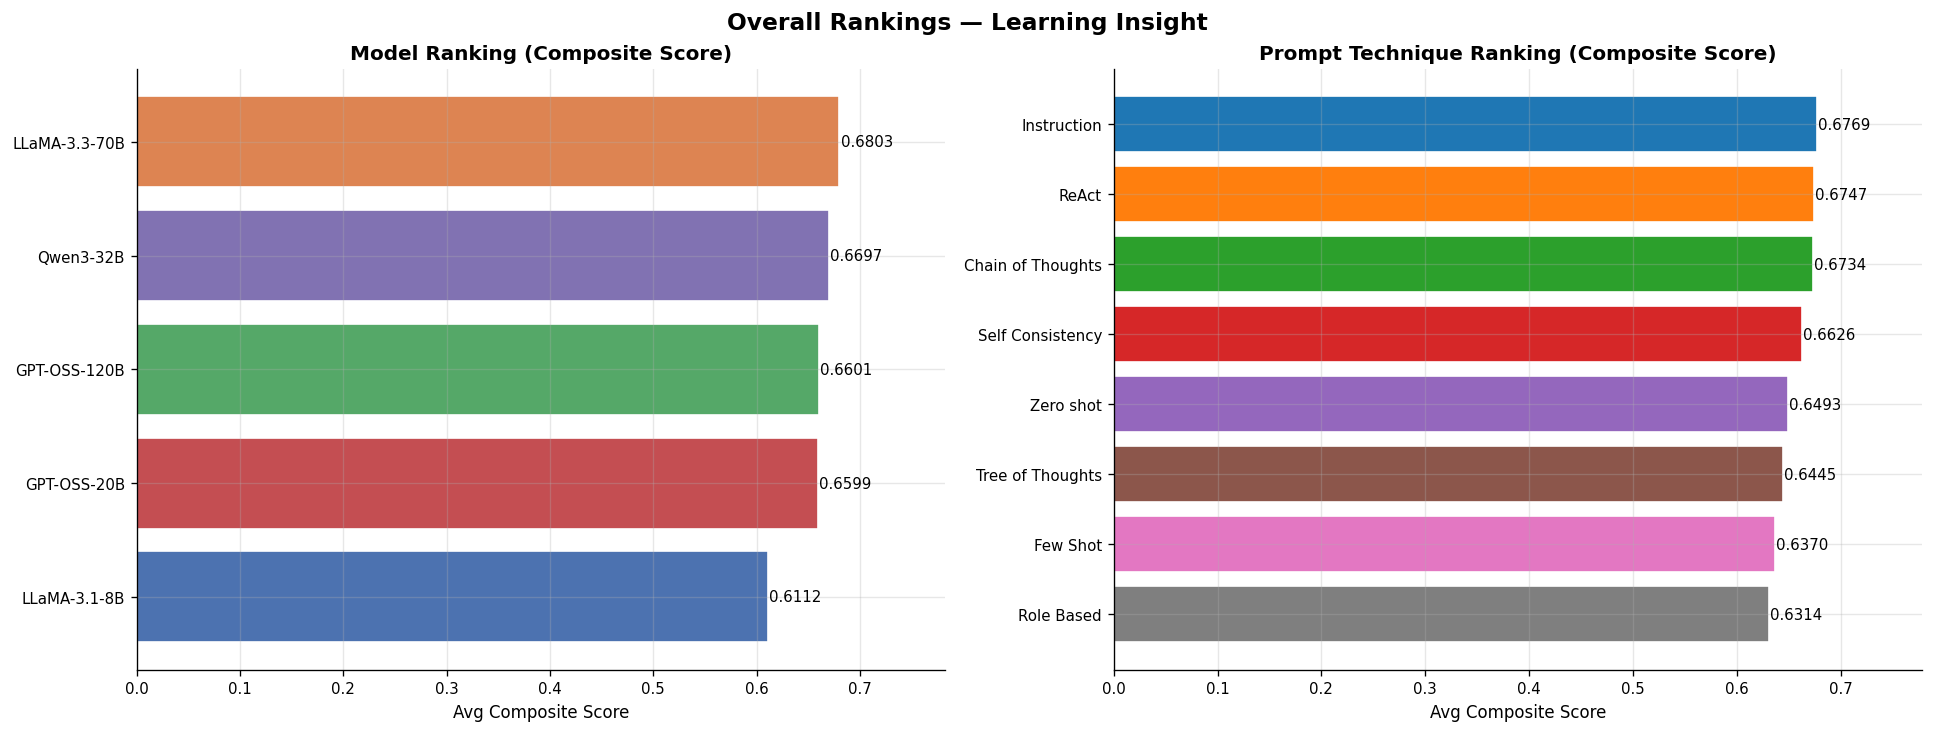

In [ ]:
model_composite  = (
    df.groupby("Model")["composite_score"]
    .mean()
    .reindex(MODELS)
    .sort_values(ascending=False)
)
prompt_composite = (
    df.groupby("Prompting")["composite_score"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

bar_colors = [MODEL_COLORS.get(m, "gray") for m in model_composite.index]
bars = axes[0].barh(
    model_composite.index[::-1], model_composite.values[::-1],
    color=bar_colors[::-1], edgecolor="white",
)
for bar, val in zip(bars, model_composite.values[::-1]):
    axes[0].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=9,
    )
axes[0].set_title("Model Ranking (Composite Score)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Avg Composite Score", fontsize=10)
axes[0].set_xlim(0, model_composite.max() * 1.15)

prompt_colors = sns.color_palette("tab10", len(prompt_composite))
bars2 = axes[1].barh(
    prompt_composite.index[::-1], prompt_composite.values[::-1],
    color=prompt_colors[::-1], edgecolor="white",
)
for bar, val in zip(bars2, prompt_composite.values[::-1]):
    axes[1].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=9,
    )
axes[1].set_title("Prompt Technique Ranking (Composite Score)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Composite Score", fontsize=10)
axes[1].set_xlim(0, prompt_composite.max() * 1.15)

fig.suptitle("Overall Rankings — Learning Insight", fontsize=14, fontweight="bold")
plt.savefig("li_overall_rankings.png", bbox_inches="tight")
plt.show()

## 16. Summary Statistics Table

In [ ]:
summary_metrics   = [
    "avg_field_completeness", "avg_bert_f1", "avg_rouge_l",
    "avg_field_bleu", "composite_score", "avg_latency_sec",
]
available_summary = [m for m in summary_metrics if df[m].notna().sum() > 0]

stats_df = (
    df.groupby(["Model", "Prompting"])[available_summary]
    .mean()
    .round(4)
    .reset_index()
)

print("Full Summary Statistics (mean per Model x Prompt):")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
print(stats_df.to_string(index=False))

Full Summary Statistics (mean per Model x Prompt):
        Model         Prompting  avg_field_completeness  avg_bert_f1  avg_rouge_l  avg_field_bleu  composite_score  avg_latency_sec
 GPT-OSS-120B Chain of Thoughts                  1.0000       0.8558       0.2504          0.1061           0.6583           2.4050
 GPT-OSS-120B          Few Shot                  1.0000       0.8596       0.2435          0.0412           0.6487           3.6008
 GPT-OSS-120B       Instruction                  1.0000       0.8748       0.2949          0.1060           0.6748           1.5608
 GPT-OSS-120B             ReAct                  1.0000       0.8617       0.2771          0.1227           0.6685           2.2463
 GPT-OSS-120B        Role Based                  1.0000       0.8491       0.2345          0.0912           0.6502           1.6567
 GPT-OSS-120B  Self Consistency                  1.0000       0.8659       0.2728          0.1128           0.6678           2.3529
 GPT-OSS-120B  Tree of Th